# AuraSync — BSEC2 IAQ Experiment
**Plan C**: Retrain IAQ classifier using only post-May 6 sessions (BSEC2 firmware),
adding Bosch's calibrated `iaq` score as an extra feature alongside our existing features.

**Shower CNN is unchanged** — this notebook only touches the IAQ classifier.

| | Round 2 Baseline | BSEC2-IAQ (this notebook) |
|---|---|---|
| Sessions | All 43 (pre + post May 6) | Post-May 6 only (~14 sessions) |
| IAQ feature | `gas_norm` rule-based | `gas_norm` + Bosch `iaq` score |
| `iaq` filter | — | `iaq_accuracy ≥ 1` (calibrated only) |
| Labels | Rule-based (our thresholds) | Rule-based (same thresholds) |

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from zoneinfo import ZoneInfo
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score
)
from sklearn.model_selection import GroupKFold

warnings.filterwarnings('ignore')
PDT = ZoneInfo('America/Los_Angeles')

ROOT      = os.path.abspath('.')
PROC_DIR  = os.path.join(ROOT, 'Data', 'processed')
MODEL_DIR = os.path.join(ROOT, 'Data', 'models')

CLASSES = ['Good', 'Moderate', 'Poor']
BSEC2_DATE = '20260506'

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Setup complete.')

Setup complete.


---
## 1. BSEC2 Data Overview

Load `all_features.csv` and examine the post-May 6 sessions that have BSEC2 `iaq` data.

In [2]:
all_feat = pd.read_csv(os.path.join(PROC_DIR, 'all_features.csv'), parse_dates=['datetime_utc'])
if all_feat['datetime_utc'].dt.tz is None:
    all_feat['datetime_utc'] = all_feat['datetime_utc'].dt.tz_localize('UTC')
all_feat['datetime_local'] = all_feat['datetime_utc'].dt.tz_convert(PDT)

# Separate pre / post BSEC2
bsec2_mask = all_feat['session_id'] >= BSEC2_DATE
pre  = all_feat[~bsec2_mask]
post = all_feat[bsec2_mask]

print('=== All sessions ===')
print(f'Total readings : {len(all_feat):,}')
print(f'Sessions       : {all_feat["session_id"].nunique()}')
print()
print('=== Pre-BSEC2 (before May 6) ===')
print(f'Readings : {len(pre):,}  |  Sessions: {pre["session_id"].nunique()}')
print(f'iaq available: {pre["iaq"].notna().sum()} readings')
print()
print('=== Post-BSEC2 (May 6 onward) ===')
print(f'Readings : {len(post):,}  |  Sessions: {post["session_id"].nunique()}')
print(f'iaq available        : {post["iaq"].notna().sum()} readings')
print(f'iaq_accuracy >= 1    : {(post["iaq_accuracy"] >= 1).sum()} readings')
print(f'iaq_accuracy >= 2    : {(post["iaq_accuracy"] >= 2).sum()} readings')
print(f'iaq_accuracy == 3    : {(post["iaq_accuracy"] == 3).sum()} readings')

# iaq_accuracy distribution
print()
print('iaq_accuracy distribution (post-BSEC2):')
print(post['iaq_accuracy'].value_counts().sort_index().to_string())

=== All sessions ===
Total readings : 47,738


Sessions       : 43

=== Pre-BSEC2 (before May 6) ===
Readings : 30,505  |  Sessions: 17
iaq available: 13578 readings

=== Post-BSEC2 (May 6 onward) ===
Readings : 17,233  |  Sessions: 26
iaq available        : 17233 readings
iaq_accuracy >= 1    : 16525 readings
iaq_accuracy >= 2    : 16525 readings
iaq_accuracy == 3    : 15063 readings

iaq_accuracy distribution (post-BSEC2):
iaq_accuracy
0.0      708
2.0     1462
3.0    15063


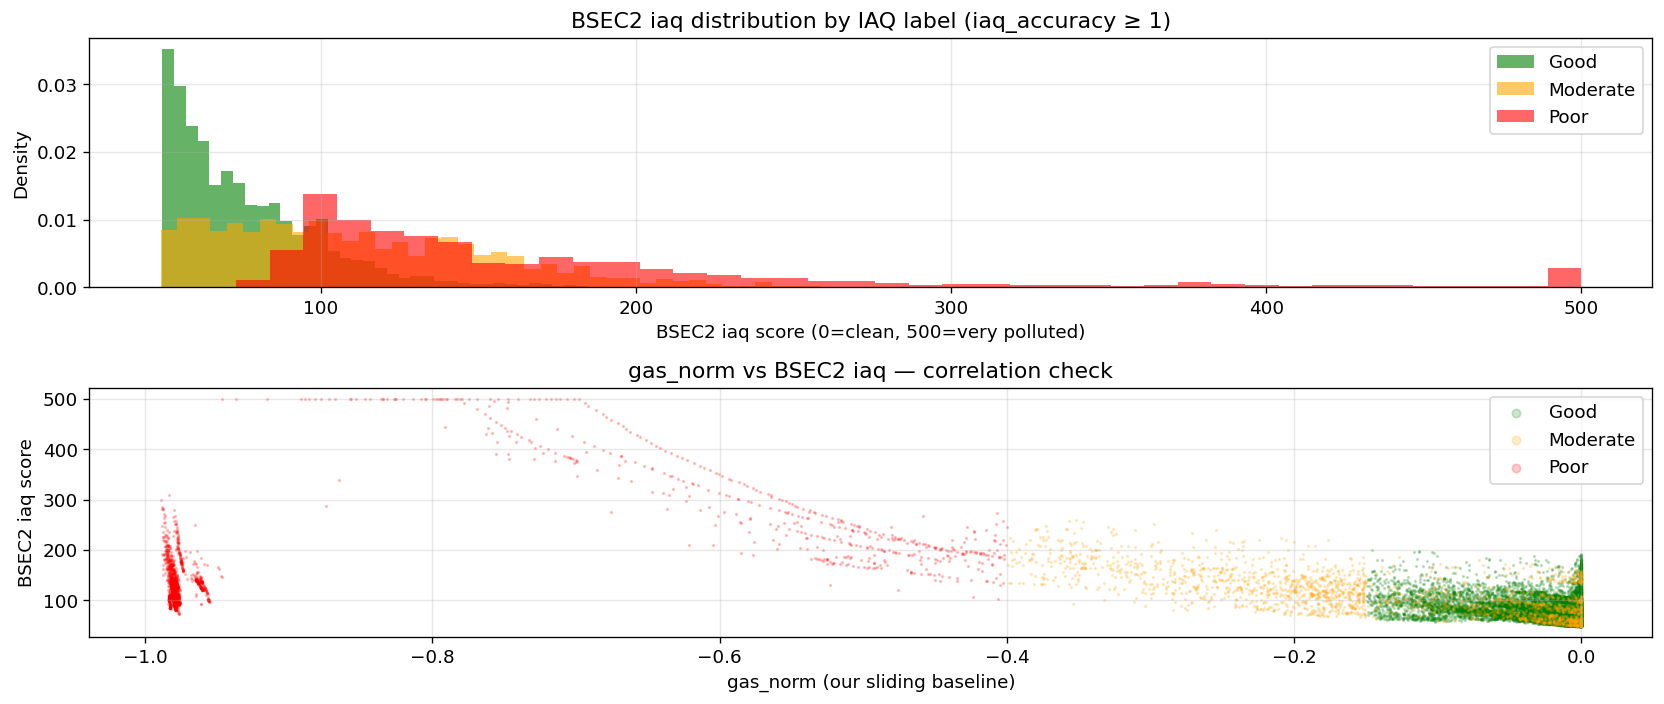

Pearson correlation gas_norm ↔ iaq: -0.5307
(Strong negative expected: gas_norm drops when iaq rises)


In [3]:
# Plot: BSEC2 iaq vs our gas_norm for post-May 6 sessions
calibrated = post[post['iaq_accuracy'] >= 1].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

# iaq distribution by iaq_label
for label, color in zip(CLASSES, ['green', 'orange', 'red']):
    subset = calibrated[calibrated['iaq_label'] == label]['iaq'].dropna()
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=label, density=True)
axes[0].set_xlabel('BSEC2 iaq score (0=clean, 500=very polluted)')
axes[0].set_ylabel('Density')
axes[0].set_title('BSEC2 iaq distribution by IAQ label (iaq_accuracy ≥ 1)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scatter: gas_norm vs iaq (coloured by iaq_label)
colors_map = {'Good': 'green', 'Moderate': 'orange', 'Poor': 'red'}
for label, color in colors_map.items():
    s = calibrated[calibrated['iaq_label'] == label]
    axes[1].scatter(s['gas_norm'], s['iaq'], s=1, alpha=0.2, color=color, label=label)
axes[1].set_xlabel('gas_norm (our sliding baseline)')
axes[1].set_ylabel('BSEC2 iaq score')
axes[1].set_title('gas_norm vs BSEC2 iaq — correlation check')
axes[1].legend(markerscale=5)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

corr = calibrated[['gas_norm', 'iaq']].corr().iloc[0, 1]
print(f'Pearson correlation gas_norm ↔ iaq: {corr:.4f}')
print('(Strong negative expected: gas_norm drops when iaq rises)')

---
## 2. Build BSEC2-IAQ Dataset

Filter to post-May 6 sessions with `iaq_accuracy ≥ 1`, add `iaq` to feature set,
and re-split by session (GroupKFold).

In [4]:
# Filter: post-BSEC2 + calibrated iaq only
df = all_feat[
    (all_feat['session_id'] >= BSEC2_DATE) &
    (all_feat['iaq_accuracy'] >= 1)
].copy().dropna(subset=['iaq', 'iaq_label'])

# Feature sets
BASE_FEATURES = [
    'temp_c', 'humidity_pct', 'gas_norm',
    'humidity_delta_5m', 'temp_delta_5m', 'gas_delta_5m',
    'humidity_max_10m', 'gas_min_10m',
    'hour_sin', 'hour_cos',
]
BSEC2_FEATURES = BASE_FEATURES + ['iaq']   # add BSEC2 score

df = df.dropna(subset=BASE_FEATURES)

le = LabelEncoder().fit(CLASSES)
df['label_enc'] = le.transform(df['iaq_label'])

print(f'BSEC2 dataset: {len(df):,} readings  |  {df["session_id"].nunique()} sessions')
print(f'Feature set  : {len(BSEC2_FEATURES)} features ({BASE_FEATURES} + [iaq])')
print()
print('Label distribution:')
print(df['iaq_label'].value_counts().to_string())
print()
print('Sessions in each Round 2 split (for reference):')
print(df.groupby('split')['session_id'].nunique().to_string())

BSEC2 dataset: 15,991 readings  |  23 sessions
Feature set  : 11 features (['temp_c', 'humidity_pct', 'gas_norm', 'humidity_delta_5m', 'temp_delta_5m', 'gas_delta_5m', 'humidity_max_10m', 'gas_min_10m', 'hour_sin', 'hour_cos'] + [iaq])

Label distribution:
iaq_label
Good        12500
Moderate     2099
Poor         1392

Sessions in each Round 2 split (for reference):
split
test      3
train    17
val       3


---
## 3. Train & Evaluate — 5-fold GroupKFold CV

Two runs:
- **Baseline** (post-May 6 data, no `iaq` feature) → isolates the effect of fewer sessions
- **+BSEC2** (post-May 6 data, with `iaq` feature) → shows pure benefit of the iaq score

In [5]:
def run_cv(df, features, label='experiment', n_splits=5):
    X      = df[features].values
    y      = df['label_enc'].values
    groups = df['session_id'].values
    all_labels = list(range(len(CLASSES)))

    gkf = GroupKFold(n_splits=n_splits)
    rf_f1s, mlp_f1s = [], []

    for fold, (tr, va) in enumerate(gkf.split(X, y, groups)):
        rf = Pipeline([('scaler', StandardScaler()),
                       ('clf', RandomForestClassifier(n_estimators=200, max_depth=10,
                                                       min_samples_leaf=5,
                                                       class_weight='balanced',
                                                       random_state=42, n_jobs=-1))])
        mlp = Pipeline([('scaler', StandardScaler()),
                        ('clf', MLPClassifier(hidden_layer_sizes=(64, 32),
                                              max_iter=300, random_state=42))])
        rf.fit(X[tr], y[tr])
        mlp.fit(X[tr], y[tr])

        rf_f1  = f1_score(y[va], rf.predict(X[va]),   average='macro',
                          labels=all_labels, zero_division=0)
        mlp_f1 = f1_score(y[va], mlp.predict(X[va]), average='macro',
                          labels=all_labels, zero_division=0)
        rf_f1s.append(rf_f1)
        mlp_f1s.append(mlp_f1)

    print(f'[{label}]  RF  Macro F1: {np.mean(rf_f1s):.4f} ± {np.std(rf_f1s):.4f}')
    print(f'[{label}]  MLP Macro F1: {np.mean(mlp_f1s):.4f} ± {np.std(mlp_f1s):.4f}')
    return np.mean(rf_f1s), np.std(rf_f1s), np.mean(mlp_f1s), np.std(mlp_f1s)

print('--- Post-May 6, WITHOUT iaq feature (baseline) ---')
rf_base_mean, rf_base_std, mlp_base_mean, mlp_base_std = run_cv(
    df, BASE_FEATURES, label='post-May6 base')
print()
print('--- Post-May 6, WITH iaq feature (BSEC2) ---')
rf_bsec_mean, rf_bsec_std, mlp_bsec_mean, mlp_bsec_std = run_cv(
    df, BSEC2_FEATURES, label='post-May6 +iaq')

--- Post-May 6, WITHOUT iaq feature (baseline) ---


[post-May6 base]  RF  Macro F1: 0.9251 ± 0.1490
[post-May6 base]  MLP Macro F1: 0.8851 ± 0.1350

--- Post-May 6, WITH iaq feature (BSEC2) ---


[post-May6 +iaq]  RF  Macro F1: 0.9252 ± 0.1491
[post-May6 +iaq]  MLP Macro F1: 0.8711 ± 0.1372


---
## 4. Train Final Model + Test Evaluation

In [6]:
# Use Round 2 split assignments for test set (same held-out sessions)
train_df = df[df['split'] == 'train']
val_df   = df[df['split'] == 'val']
test_df  = df[df['split'] == 'test']

print(f'Train: {len(train_df):,} readings ({train_df["session_id"].nunique()} sessions)')
print(f'Val  : {len(val_df):,} readings ({val_df["session_id"].nunique()} sessions)')
print(f'Test : {len(test_df):,} readings ({test_df["session_id"].nunique()} sessions)')

# Train both feature sets on full train split
all_labels = list(range(len(CLASSES)))

def train_best(train_df, val_df, features):
    X_tr, y_tr = train_df[features].values, train_df['label_enc'].values
    X_va, y_va = val_df[features].values,   val_df['label_enc'].values

    rf = Pipeline([('scaler', StandardScaler()),
                   ('clf', RandomForestClassifier(n_estimators=200, max_depth=10,
                                                   min_samples_leaf=5,
                                                   class_weight='balanced',
                                                   random_state=42, n_jobs=-1))])
    mlp = Pipeline([('scaler', StandardScaler()),
                    ('clf', MLPClassifier(hidden_layer_sizes=(64, 32),
                                          max_iter=300, random_state=42))])
    rf.fit(X_tr, y_tr);  mlp.fit(X_tr, y_tr)

    rf_f1  = f1_score(y_va, rf.predict(X_va),   average='macro', labels=all_labels, zero_division=0)
    mlp_f1 = f1_score(y_va, mlp.predict(X_va), average='macro', labels=all_labels, zero_division=0)
    best   = rf if rf_f1 >= mlp_f1 else mlp
    best_name = 'RF' if rf_f1 >= mlp_f1 else 'MLP'
    print(f'  Val F1 → RF: {rf_f1:.4f}  MLP: {mlp_f1:.4f}  → Best: {best_name}')
    return best, best_name, rf

print('\n[Without iaq]')
model_base, name_base, rf_base = train_best(train_df, val_df, BASE_FEATURES)

print('\n[With iaq]')
model_bsec, name_bsec, rf_bsec = train_best(train_df, val_df, BSEC2_FEATURES)

Train: 14,360 readings (17 sessions)
Val  : 355 readings (3 sessions)
Test : 1,276 readings (3 sessions)

[Without iaq]


  Val F1 → RF: 1.0000  MLP: 0.9767  → Best: RF

[With iaq]


  Val F1 → RF: 1.0000  MLP: 0.9565  → Best: RF


In [7]:
# Test evaluation for both models
def eval_test(model, test_df, features, label):
    if len(test_df) == 0:
        print(f'[{label}] No test data in BSEC2 split.')
        return 0.0
    X_te = test_df[features].values
    y_te = test_df['label_enc'].values
    y_pr = model.predict(X_te)
    f1   = f1_score(y_te, y_pr, average='macro', labels=all_labels, zero_division=0)
    print(f'\n[{label}]  Test Macro F1: {f1:.4f}')
    print(classification_report(y_te, y_pr, target_names=CLASSES, zero_division=0))
    return f1

f1_base_test = eval_test(model_base, test_df, BASE_FEATURES, 'post-May6 base')
f1_bsec_test = eval_test(model_bsec, test_df, BSEC2_FEATURES, 'post-May6 +iaq')


[post-May6 base]  Test Macro F1: 1.0000
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00      1112
    Moderate       1.00      1.00      1.00        56
        Poor       1.00      1.00      1.00       108

    accuracy                           1.00      1276
   macro avg       1.00      1.00      1.00      1276
weighted avg       1.00      1.00      1.00      1276


[post-May6 +iaq]  Test Macro F1: 1.0000
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00      1112
    Moderate       1.00      1.00      1.00        56
        Poor       1.00      1.00      1.00       108

    accuracy                           1.00      1276
   macro avg       1.00      1.00      1.00      1276
weighted avg       1.00      1.00      1.00      1276



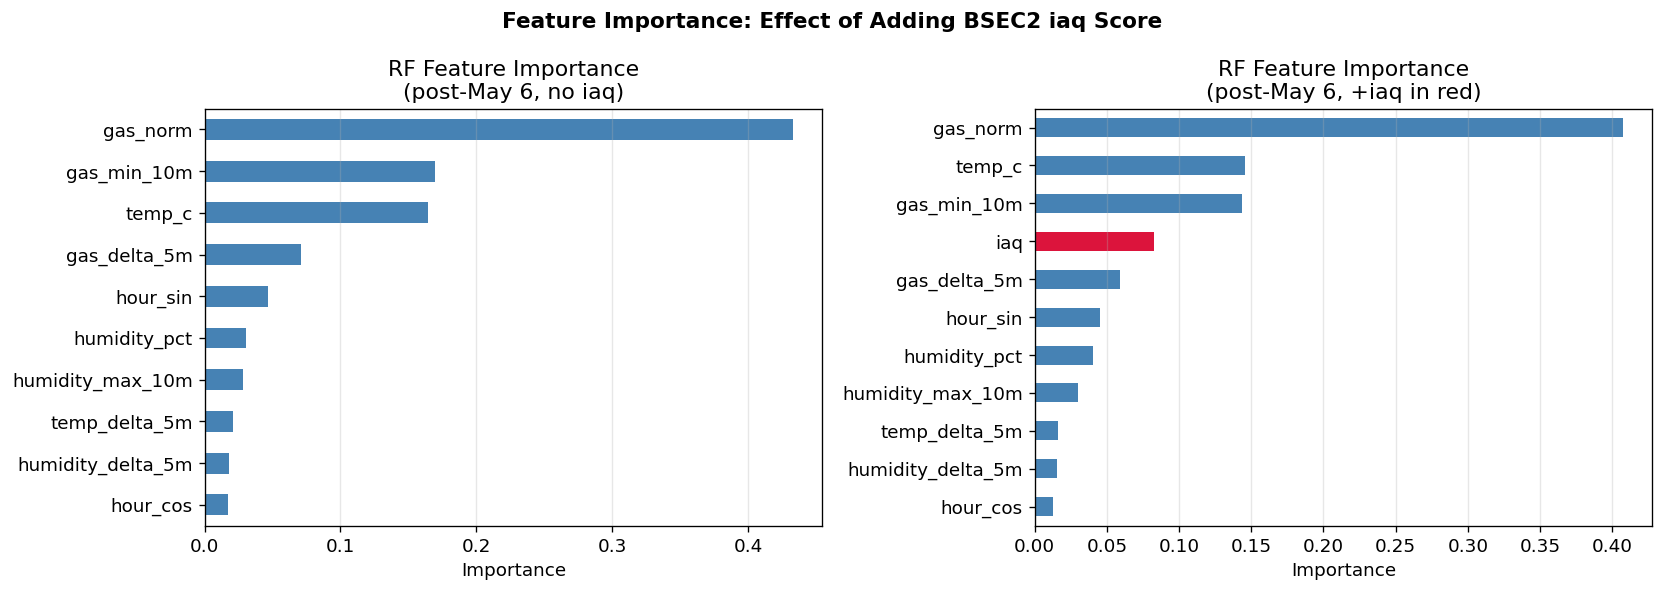

In [8]:
# Feature importance comparison (RF only)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

imp_base = pd.Series(rf_base.named_steps['clf'].feature_importances_,
                     index=BASE_FEATURES).sort_values(ascending=True)
imp_bsec = pd.Series(rf_bsec.named_steps['clf'].feature_importances_,
                     index=BSEC2_FEATURES).sort_values(ascending=True)

imp_base.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('RF Feature Importance\n(post-May 6, no iaq)')
ax1.set_xlabel('Importance')
ax1.grid(axis='x', alpha=0.3)

colors = ['crimson' if f == 'iaq' else 'steelblue' for f in imp_bsec.index]
imp_bsec.plot(kind='barh', ax=ax2, color=colors)
ax2.set_title('RF Feature Importance\n(post-May 6, +iaq in red)')
ax2.set_xlabel('Importance')
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance: Effect of Adding BSEC2 iaq Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'bsec2_iaq_feat_imp.png'), dpi=120, bbox_inches='tight')
plt.show()

---
## 5. Save Best BSEC2 Model

In [9]:
os.makedirs(MODEL_DIR, exist_ok=True)
bsec2_path = os.path.join(MODEL_DIR, 'iaq_bsec2_v1.pkl')
joblib.dump({
    'model':         model_bsec,
    'label_encoder': le,
    'features':      BSEC2_FEATURES,
    'model_type':    name_bsec,
    'note':          'Post-May 6 sessions only, iaq_accuracy >= 1, includes BSEC2 iaq feature'
}, bsec2_path)
print(f'Saved BSEC2 IAQ model → {bsec2_path}')

Saved BSEC2 IAQ model → C:\Users\华硕\Desktop\TECHIN-515-Team6\Data\models\iaq_bsec2_v1.pkl


---
## 6. Final Comparison: Round 2 vs BSEC2-IAQ

In [10]:
# Round 2 reference numbers (from AuraSync_ML_Round2.ipynb)
R2_CV_MEAN  = 0.9894
R2_CV_STD   = 0.0121
R2_TEST_F1  = 0.9879
R2_SESSIONS = 43
R2_READINGS = 47738

comparison = pd.DataFrame([
    {'Metric': 'Sessions',
     'Round 2 (all)': str(R2_SESSIONS),
     'Post-May 6 (no iaq)': str(df["session_id"].nunique()),
     'Post-May 6 (+iaq)': str(df["session_id"].nunique())},
    {'Metric': 'Readings',
     'Round 2 (all)': f'{R2_READINGS:,}',
     'Post-May 6 (no iaq)': f'{len(df):,}',
     'Post-May 6 (+iaq)': f'{len(df):,}'},
    {'Metric': 'Features',
     'Round 2 (all)': '10 (no iaq)',
     'Post-May 6 (no iaq)': '10 (no iaq)',
     'Post-May 6 (+iaq)': '11 (+iaq)'},
    {'Metric': 'CV Macro F1',
     'Round 2 (all)': f'{R2_CV_MEAN:.4f} ± {R2_CV_STD:.4f}',
     'Post-May 6 (no iaq)': f'{rf_base_mean:.4f} ± {rf_base_std:.4f}  (RF)',
     'Post-May 6 (+iaq)': f'{rf_bsec_mean:.4f} ± {rf_bsec_std:.4f}  (RF)'},
    {'Metric': 'CV Macro F1 (MLP)',
     'Round 2 (all)': '0.9487',
     'Post-May 6 (no iaq)': f'{mlp_base_mean:.4f} ± {mlp_base_std:.4f}',
     'Post-May 6 (+iaq)': f'{mlp_bsec_mean:.4f} ± {mlp_bsec_std:.4f}'},
    {'Metric': 'Test Macro F1',
     'Round 2 (all)': f'{R2_TEST_F1:.4f}',
     'Post-May 6 (no iaq)': f'{f1_base_test:.4f}',
     'Post-May 6 (+iaq)': f'{f1_bsec_test:.4f}'},
])

display(comparison.style.set_caption('IAQ Model Comparison').hide(axis='index'))

print()
print('=== Interpretation ===')
delta_cv   = rf_bsec_mean - rf_base_mean
delta_test = f1_bsec_test - f1_base_test
print(f'CV F1 gain from iaq feature  : {delta_cv:+.4f}')
print(f'Test F1 gain from iaq feature: {delta_test:+.4f}')

if delta_cv > 0.005 or delta_test > 0.005:
    print('→ BSEC2 iaq feature meaningfully improves the classifier. Recommend iaq_bsec2_v1.pkl for deployment.')
else:
    print('→ BSEC2 iaq feature has minimal additional gain over gas_norm alone.')
    print('  Round 2 model (iaq_rf_v1.pkl, all sessions) remains the stronger choice for deployment.')

Metric,Round 2 (all),Post-May 6 (no iaq),Post-May 6 (+iaq)
Sessions,43,23,23
Readings,"47,738","15,991","15,991"
Features,10 (no iaq),10 (no iaq),11 (+iaq)
CV Macro F1,0.9894 ± 0.0121,0.9251 ± 0.1490 (RF),0.9252 ± 0.1491 (RF)
CV Macro F1 (MLP),0.9487,0.8851 ± 0.1350,0.8711 ± 0.1372
Test Macro F1,0.9879,1.0000,1.0000



=== Interpretation ===
CV F1 gain from iaq feature  : +0.0002
Test F1 gain from iaq feature: +0.0000
→ BSEC2 iaq feature has minimal additional gain over gas_norm alone.
  Round 2 model (iaq_rf_v1.pkl, all sessions) remains the stronger choice for deployment.
